In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# read
train = pd.read_csv('../data/Task1/crime_train.csv')

In [ ]:
# view
train

In [14]:
train.info()
display(train.describe())
np.array(train.columns)

<class 'pandas.DataFrame'>
Index: 22489 entries, 21141 to 18481
Columns: 603 entries, case_filed to police_department_42.0
dtypes: float64(2), int64(600), int8(1)
memory usage: 103.5 MB


,case_filed,age,closed,city_Ahmedabad,city_Bangalore,city_Bhopal,city_Chennai,city_Delhi,city_Faridabad,city_Ghaziabad,...,police_department_33.0,police_department_34.0,police_department_35.0,police_department_36.0,police_department_37.0,police_department_38.0,police_department_39.0,police_department_40.0,police_department_41.0,police_department_42.0
count,2.248900e+04,2.248900e+04,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,...,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000,22489.000000
mean,1.617670e-16,-1.522885e-16,0.500378,0.046111,0.087821,0.016719,0.062831,0.133888,0.008404,0.017831,...,0.001823,0.001023,0.001467,0.001512,0.002045,0.001690,0.001378,0.001156,0.001868,0.001556
std,1.000022e+00,1.000022e+00,0.500011,0.209731,0.283040,0.128220,0.242664,0.340539,0.091290,0.132340,...,0.042660,0.031964,0.038279,0.038854,0.045181,0.041072,0.037103,0.033983,0.043176,0.039420
min,-1.731576e+00,-1.703879e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-8.689830e-01,-8.687479e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-4.576917e-03,1.550826e-02,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.673405e-01,8.506391e-01,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.735632e+00,1.685770e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


array(['case_filed', 'age', 'closed', 'city_Ahmedabad', 'city_Bangalore',
       'city_Bhopal', 'city_Chennai', 'city_Delhi', 'city_Faridabad',
       'city_Ghaziabad', 'city_Hyderabad', 'city_Indore', 'city_Jaipur',
       'city_Kalyan', 'city_Kanpur', 'city_Kolkata', 'city_Lucknow',
       'city_Ludhiana', 'city_Meerut', 'city_Mumbai', 'city_Nagpur',
       'city_Nashik', 'city_Patna', 'city_Pune', 'city_Rajkot',
       'city_Srinagar', 'city_Surat', 'city_Thane', 'city_Varanasi',
       'city_Vasai', 'city_Visakhapatnam', 'area_101', 'area_102',
       'area_103', 'area_104', 'area_105', 'area_106', 'area_107',
       'area_108', 'area_109', 'area_110', 'area_111', 'area_112',
       'area_113', 'area_114', 'area_115', 'area_116', 'area_117',
       'area_118', 'area_119', 'area_120', 'area_121', 'area_122',
       'area_123', 'area_124', 'area_125', 'area_126', 'area_127',
       'area_128', 'area_129', 'area_130', 'area_131', 'area_132',
       'area_133', 'area_134', 'area_135', 

# Preprocess

In [4]:
train.sort_values('Num', inplace=True)
train.drop(columns=['Unnamed: 0', 'Num'], inplace=True)

print(train.duplicated().sum())

0


In [5]:
train.case_filed = pd.to_datetime(train.case_filed)
min_case_filed = train.case_filed.min()
train.case_filed = (train.case_filed - min_case_filed).dt.total_seconds()

In [6]:
uniques = dict()
train.area.value_counts()
uniques['area'] = train.area.unique()
train.city.value_counts()
uniques['city'] = train.city.unique()
train.crime_description.value_counts()
uniques['crime_description'] = train.crime_description.unique()
train.domain.value_counts()
uniques['domain'] = train.domain.unique()
np.sort(train.area.unique())

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203,
       204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216,
       217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229,
       230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242,
       243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255,
       256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268,
       269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 28

In [7]:
print(train.weapon.isna().sum())
train.weapon.value_counts()
train.weapon = train.weapon.fillna('None')  # no weapon used is significant
uniques['weapon'] = train.weapon.unique()

3272


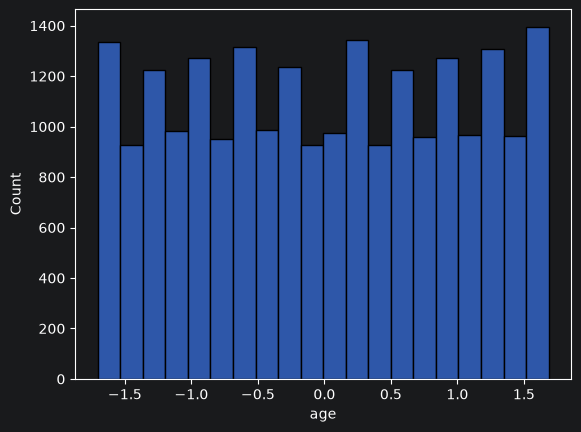

In [12]:
sns.histplot(train.age, bins=20)
plt.show()
train.age = np.clip(train.age, *np.percentile(train.age, [1, 99]))  # unrealistic ages clipped

In [9]:
train.police_department.value_counts()
train.police_department = np.round(train.police_department) # for those ending with .9
uniques['police_department'] = train.police_department.unique()
np.sort(train.police_department.unique())

array([-4., -3., -2., -1., -0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,
        9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42.])

In [10]:
train.closed = train.closed.astype('category').cat.codes    # binary encoding
# one-hot encoding
train = pd.get_dummies(train, columns=['city', 'area', 'crime_description', 'sex', 'weapon', 'domain', 'police_department'], dtype=int, drop_first=True)

In [11]:
# feature scaling
case_filed_mean, case_filed_std = np.mean(train.case_filed), np.std(train.case_filed)
age_mean, age_std = np.mean(train.age), np.std(train.age)
train.case_filed = (train.case_filed - case_filed_mean) / case_filed_std
train.age = (train.age - age_mean) / age_std

# Train

In [15]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    if x >= 0:
        return 1 / (1 + np.exp(-x))
    return np.exp(x) / (1 + np.exp(x))

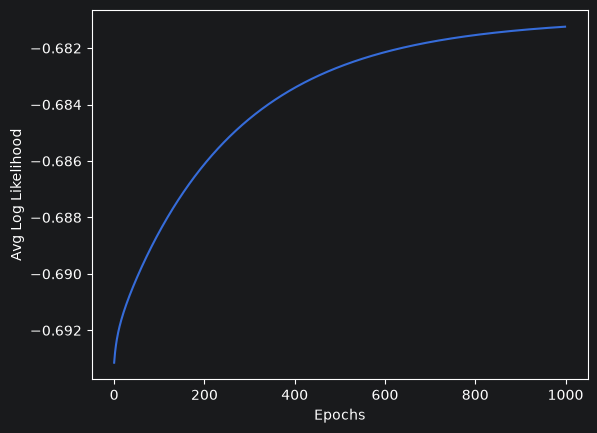

In [16]:
EPOCHS = 1000

tiny = 1e-15
x = np.hstack([np.ones((train.index.size, 1)), np.array(train.drop(columns=['closed']))])
y = np.array(train[['closed']])
weights = np.zeros((x.shape[1], 1))
alpha = 4
ll = np.zeros(EPOCHS)
for i in range(EPOCHS):
    hx = np.clip(np.vectorize(sigmoid)(x @ weights), tiny, 1-tiny)
    weights -= alpha * x.T @ (hx - y) / x.shape[0]
    ll[i] = np.sum(y * np.log(hx) + (1 - y) * np.log(1 - hx)) / x.shape[0]

plt.xlabel('Epochs')
plt.ylabel('Avg Log Likelihood')
plt.plot(ll)
plt.show()

# Preprocess Test Dataset

In [17]:
test = pd.read_csv('../data/Task1/crime_test.csv')

In [ ]:
test

In [31]:
test.info()
display(test.describe())
np.array(test.columns)

<class 'pandas.DataFrame'>
Index: 9639 entries, 7988 to 3763
Columns: 603 entries, case_filed to police_department_42.0
dtypes: float64(2), int64(600), int8(1)
memory usage: 44.4 MB


,case_filed,age,closed,city_Ahmedabad,city_Bangalore,city_Bhopal,city_Chennai,city_Delhi,city_Faridabad,city_Ghaziabad,...,police_department_33.0,police_department_34.0,police_department_35.0,police_department_36.0,police_department_37.0,police_department_38.0,police_department_39.0,police_department_40.0,police_department_41.0,police_department_42.0
count,9639.000000,9639.000000,9639.000000,9639.000000,9639.000000,9639.000000,9639.000000,9639.000000,9639.000000,9639.000000,...,9639.000000,9639.000000,9639.000000,9639.000000,9639.000000,9639.00000,9639.000000,9639.000000,9639.000000,9639.000000
mean,0.010362,0.000216,0.500363,0.045648,0.091088,0.017844,0.059757,0.133624,0.009026,0.015977,...,0.001349,0.001764,0.001764,0.001867,0.001245,0.00166,0.001452,0.001971,0.001764,0.002386
std,0.997177,1.015325,0.500026,0.208731,0.287750,0.132392,0.237049,0.340265,0.094580,0.125392,...,0.036702,0.041961,0.041961,0.043175,0.035264,0.04071,0.038085,0.044356,0.041961,0.048792
min,-1.731144,-1.703879,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,-0.844204,-0.868748,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.010014,-0.033617,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,0.867815,0.894852,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,1.735200,1.945368,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


array(['case_filed', 'age', 'closed', 'city_Ahmedabad', 'city_Bangalore',
       'city_Bhopal', 'city_Chennai', 'city_Delhi', 'city_Faridabad',
       'city_Ghaziabad', 'city_Hyderabad', 'city_Indore', 'city_Jaipur',
       'city_Kalyan', 'city_Kanpur', 'city_Kolkata', 'city_Lucknow',
       'city_Ludhiana', 'city_Meerut', 'city_Mumbai', 'city_Nagpur',
       'city_Nashik', 'city_Patna', 'city_Pune', 'city_Rajkot',
       'city_Srinagar', 'city_Surat', 'city_Thane', 'city_Varanasi',
       'city_Vasai', 'city_Visakhapatnam', 'area_101', 'area_102',
       'area_103', 'area_104', 'area_105', 'area_106', 'area_107',
       'area_108', 'area_109', 'area_110', 'area_111', 'area_112',
       'area_113', 'area_114', 'area_115', 'area_116', 'area_117',
       'area_118', 'area_119', 'area_120', 'area_121', 'area_122',
       'area_123', 'area_124', 'area_125', 'area_126', 'area_127',
       'area_128', 'area_129', 'area_130', 'area_131', 'area_132',
       'area_133', 'area_134', 'area_135', 

In [20]:
test.sort_values('Num', inplace=True)
test.drop(columns=['Unnamed: 0', 'Num'], inplace=True)

print(test.duplicated().sum())

0


In [21]:
test.case_filed = pd.to_datetime(test.case_filed)
test.case_filed = (test.case_filed - min_case_filed).dt.total_seconds()

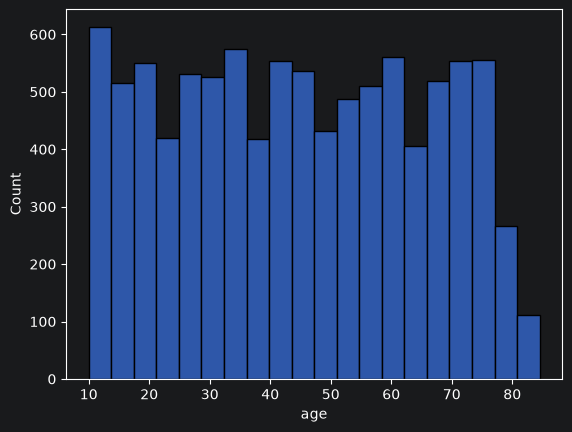

In [23]:
sns.histplot(test.age, bins=20)
plt.show()
test.age = np.clip(test.age, *np.percentile(test.age, [1, 99]))

In [24]:
print(test.weapon.isna().sum())
test.weapon.value_counts()
test.weapon = test.weapon.fillna('None')

1364


In [25]:
test.police_department.value_counts()
test.police_department = np.round(test.police_department)
np.sort(test.police_department.unique())

array([-4., -3., -2., -1., -0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,
        9., 10., 11., 12., 13., 14., 15., 16., 17., 18., 19., 24., 25.,
       26., 27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38.,
       39., 40., 41., 42.])

In [26]:
# check if there's any categorical value other than the ones in the training dataset
np.any([np.any(~test[col].isin(uniques[col])) for col in uniques])

np.False_

In [27]:
test.closed = test.closed.astype('category').cat.codes
test = pd.get_dummies(test, columns=['city', 'area', 'crime_description', 'sex', 'weapon', 'domain', 'police_department'], dtype=int, drop_first=True)

In [28]:
test.case_filed = (test.case_filed - case_filed_mean) / case_filed_std
test.age = (test.age - age_mean) / age_std

In [29]:
np.all(train.columns == test.columns)   # check feature order

np.True_

# Test

In [32]:
x = np.hstack([np.ones((test.index.size, 1)), np.array(test.drop(columns=['closed']))])
y = np.array(test[['closed']])

hx = (np.vectorize(sigmoid)(x @ weights) >= 0.5).astype(int)[:,0]
print(f'Accuracy = {np.mean(hx == y[:,0]) * 100:.2f}%')

Accuracy = 49.52%
